# DANDI Dataset Example with Experanto
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DebDDash/experanto-dandi-example/blob/main/dandi_experanto_example.ipynb)

This notebook demonstrates how to load a [DANDI Archive](https://dandiarchive.org) dataset
into [Experanto](https://github.com/sensorium-competition/experanto) format.

**Dataset:** [MC_Maze (DANDI:000128)](https://dandiarchive.org/dandiset/000128) —
Macaque motor cortex spiking activity during delayed reaching task.

**What this notebook covers:**
1. Downloading a DANDI dataset programmatically
2. Extracting spike times from NWB format
3. Converting to Experanto's sequence format
4. Loading and querying via `Experiment.interpolate()`
5. Visualizing neural activity patterns
```

In [1]:
# Install dependencies
!pip install experanto git+https://github.com/sensorium-competition/experanto.git
!pip install dandi pynwb numpy matplotlib PyYAML
!pip install hydra-core --upgrade

  Cloning https://github.com/sensorium-competition/experanto.git to /tmp/pip-req-build-nsw4z0k9
  Running command git clone --filter=blob:none --quiet https://github.com/sensorium-competition/experanto.git /tmp/pip-req-build-nsw4z0k9
  Resolved https://github.com/sensorium-competition/experanto.git to commit 245557433246c303abd0b76eabedad518f029906
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for experanto: filename=experanto-0.1-py3-none-any.whl size=30211 sha256=867048c125defaed663d1dfd77f703a0a712a654e99ab4d64d1d97ecd7717b9e
  Stored in directory: /tmp/pip-ephem-wheel-cache-aqzc1ke3/wheels/03/d9/4f/3aa851ad2d02a21ec2fa6872ad8f4bae809a627104f6c2536d
Successfully built experanto
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.3 MB/s eta 0:00:00
   ━━━━

In [2]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient

print("All imports successful!")

All imports successful!


In [3]:
os.makedirs("data", exist_ok=True)

client = DandiAPIClient()
dandiset = client.get_dandiset("000128")
assets = list(dandiset.get_assets())

# Use the small test file (3.39 MB)
asset = assets[0]
print(f"Downloading: {asset.path} ({round(asset.size/1e6, 2)} MB)")
asset.download("data/mc_maze_test.nwb")
print("Download complete!")

Downloading: sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb (3.39 MB)


INFO:dandi:Asset 1bd112a4-5ec5-4033-ac30-d88e70e993d9 (3392688 bytes in 1 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/1bd112a4-5ec5-4033-ac30-d88e70e993d9/download/


Download complete!


In [4]:
io = NWBHDF5IO("data/mc_maze_test.nwb", "r")
nwb = io.read()

print("Session Info")
print(f"Description: {nwb.session_description}")
print(f"Subject: {nwb.subject.subject_id} ({nwb.subject.species})")

print(f"\nNeural Data")
print(f"Number of neurons: {len(nwb.units)}")
print(f"Columns: {nwb.units.colnames}")

print(f"\nTrials")
print(f"Number of trials: {len(nwb.trials)}")
trials_df = nwb.trials.to_dataframe()
print(trials_df.head())

Session Info
Description: Data from monkey Jenkins performing center-out delayed reaching task. This file contains segments of trials from the full session on 2009-09-25 that are to be used for evaluating models for the Neural Latents Benchmark.
Subject: Jenkins (Macaca mulatta)

Neural Data
Number of neurons: 137
Columns: ('heldout', 'spike_times', 'obs_intervals', 'electrodes')

Trials
Number of trials: 574
    start_time  stop_time  move_onset_time split
id                                              
0          0.0        0.7             0.25  test
1          0.8        1.5             1.05  test
2          1.6        2.3             1.85  test
3          2.4        3.1             2.65  test
4          3.2        3.9             3.45  test


# Convert spike times to binned firing rates
## Experanto SequenceInterpolator expects:
- data.npy: shape (n_timestamps, n_neurons) float32
- meta.yml: sampling_rate, start_time, end_time, n_signals, n_timestamps

In [8]:
def convert_nwb_to_experanto(nwb, output_dir: str, bin_size_ms: float = 25.0):
    output_path = Path(output_dir)
    responses_path = output_path / "responses"
    os.makedirs(responses_path, exist_ok=True)

    trials_df = nwb.trials.to_dataframe()
    start_time = float(trials_df["start_time"].min())
    end_time = float(trials_df["stop_time"].max())

    print(f"Time range: {start_time:.2f}s to {end_time:.2f}s")
    print(f"Total duration: {end_time - start_time:.2f}s")

    bin_size_s = bin_size_ms / 1000.0
    sampling_rate = 1.0 / bin_size_s
    time_bins = np.arange(start_time, end_time, bin_size_s)
    n_timestamps = len(time_bins)

    units_df = nwb.units.to_dataframe()
    n_neurons = len(units_df)

    print(f"\nBin size: {bin_size_ms}ms → sampling rate: {sampling_rate}Hz")
    print(f"Number of time bins: {n_timestamps}")
    print(f"Number of neurons: {n_neurons}")

    # Build firing rate matrix (n_timestamps x n_neurons)
    firing_rates = np.zeros((n_timestamps, n_neurons), dtype=np.float32)

    for i, (unit_id, unit) in enumerate(units_df.iterrows()):
        spike_times = np.array(unit["spike_times"])
        counts, _ = np.histogram(spike_times, bins=np.append(time_bins, end_time))
        firing_rates[:, i] = counts.astype(np.float32)

    print(f"\nFiring rate matrix shape: {firing_rates.shape}")
    print(f"Mean firing rate: {firing_rates.mean():.4f} spikes/bin")
    print(f"Max firing rate: {firing_rates.max():.1f} spikes/bin")

    np.save(responses_path / "data.npy", firing_rates)
    print(f"\nSaved data.npy → {responses_path}/data.npy")

    meta = {
        "modality": "sequence",
        "sampling_rate": float(sampling_rate),
        "start_time": float(start_time),
        "end_time": float(end_time),
        "n_signals": int(n_neurons),
        "n_timestamps": int(n_timestamps),
        "dtype": "float32",
        "is_mem_mapped": False,
        "description": "Binned spike counts from MC_Maze NWB file (DANDI:000128)",
        "bin_size_ms": bin_size_ms,
    }

    with open(responses_path / "meta.yml", "w") as f:
        yaml.dump(meta, f, default_flow_style=False)

    print(f"Saved meta.yml → {responses_path}/meta.yml")
    return output_path, meta, firing_rates, time_bins

output_path, meta, firing_rates, time_bins = convert_nwb_to_experanto(
    nwb,
    output_dir="experanto_mc_maze",
    bin_size_ms=25.0
)

Time range: 0.00s to 459.10s
Total duration: 459.10s

Bin size: 25.0ms → sampling rate: 40.0Hz
Number of time bins: 18364
Number of neurons: 137

Firing rate matrix shape: (18364, 137)
Mean firing rate: 0.0916 spikes/bin
Max firing rate: 6.0 spikes/bin

Saved data.npy → experanto_mc_maze/responses/data.npy
Saved meta.yml → experanto_mc_maze/responses/meta.yml


In [9]:
print("Experanto folder structure")
for root, dirs, files in os.walk("experanto_mc_maze"):
    level = root.replace("experanto_mc_maze", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        fpath = os.path.join(root, file)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {indent}{file} ({size_kb:.1f} KB)")

print("\n meta.yml contents")
with open("experanto_mc_maze/responses/meta.yml") as f:
    print(f.read())

Experanto folder structure
experanto_mc_maze/
  responses/
    data.npy (9827.7 KB)
    meta.yml (0.2 KB)

 meta.yml contents
bin_size_ms: 25.0
description: Binned spike counts from MC_Maze NWB file (DANDI:000128)
dtype: float32
end_time: 459.09999999999997
is_mem_mapped: false
modality: sequence
n_signals: 137
n_timestamps: 18364
sampling_rate: 40.0
start_time: 0.0



In [10]:
from experanto.interpolators import Interpolator
from experanto.experiment import Experiment
from omegaconf import OmegaConf

modality_config = {
    "responses": {
        "interpolation": {
            "interpolation_mode": "nearest_neighbor",
        }
    }
}

experiment = Experiment(
    root_folder="experanto_mc_maze",
    modality_config=modality_config,
)

print(f"Devices found: {experiment.device_names}")
print(f"Start time: {experiment.start_time:.3f}s")
print(f"End time: {experiment.end_time:.3f}s")

Devices found: ('responses',)
Start time: 0.000s
End time: 459.100s


/usr/local/lib/python3.12/dist-packages/experanto/experiment.py:75: UserWarning: Falling back to original Interpolator creation logic.
  warnings.warn(


In [11]:
query_times = np.linspace(
    experiment.start_time,
    experiment.start_time + 5.0,
    100
)

result = experiment.interpolate(query_times)

print("Interpolation Result")
for modality, data in result.items():
    print(f"  {modality}: shape={data.shape}, dtype={data.dtype}")
    print(f"  Mean activity: {np.nanmean(data):.4f}")

Interpolation Result
  responses: shape=(100, 137), dtype=float32
  Mean activity: 0.0827


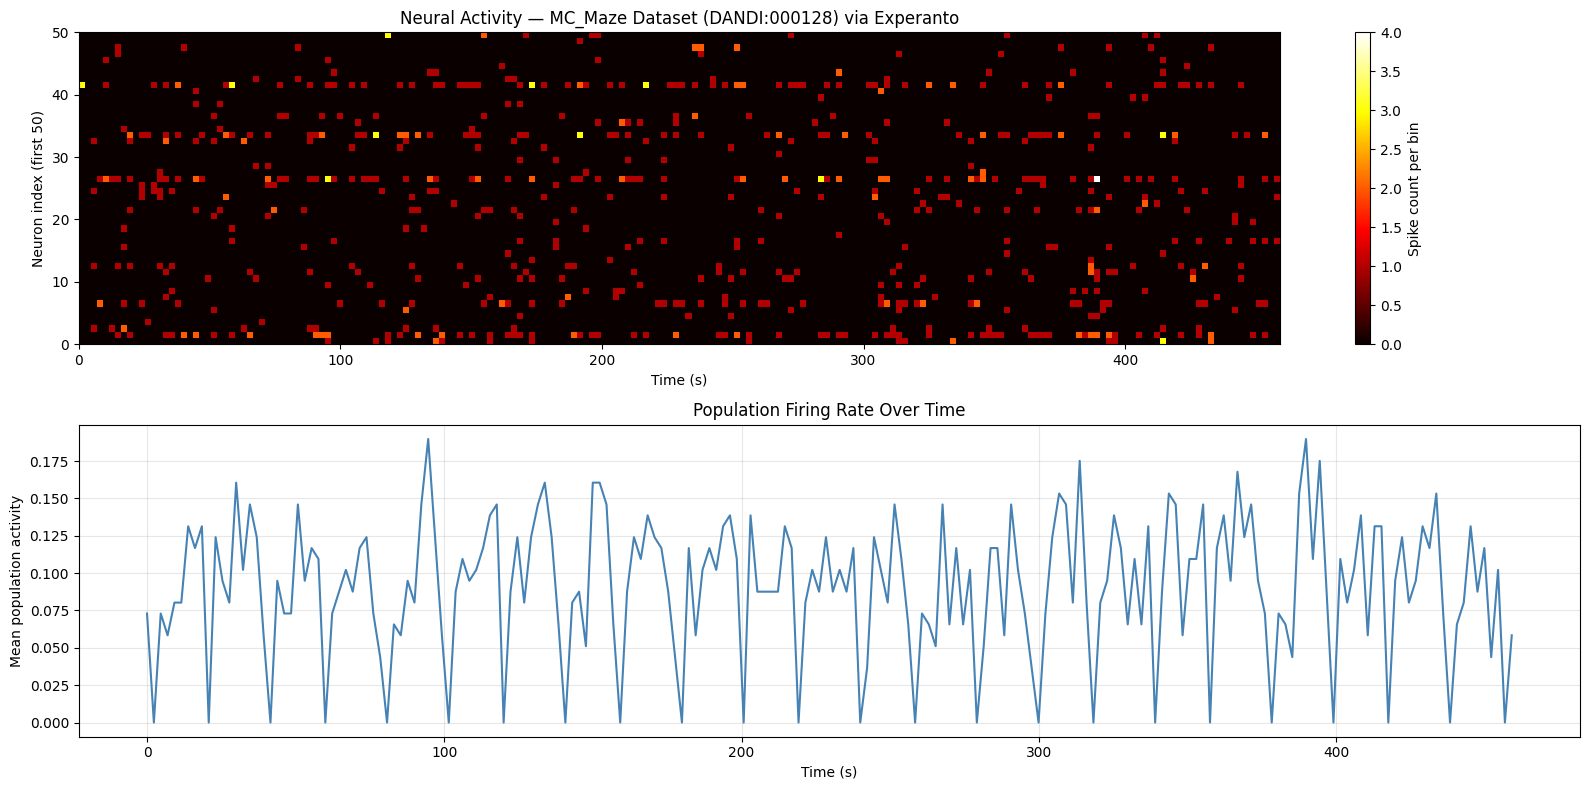

In [12]:
n_neurons_to_plot = 50
n_time_to_plot = 200

plot_times = np.linspace(
    experiment.start_time,
    experiment.end_time,
    n_time_to_plot
)
plot_result = experiment.interpolate(plot_times)
responses = plot_result["responses"]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))


ax1 = axes[0]
im = ax1.imshow(
    responses[:, :n_neurons_to_plot].T,
    aspect="auto",
    cmap="hot",
    interpolation="nearest",
    extent=[plot_times[0], plot_times[-1], 0, n_neurons_to_plot]
)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel(f"Neuron index (first {n_neurons_to_plot})")
ax1.set_title("Neural Activity — MC_Maze Dataset (DANDI:000128) via Experanto")
plt.colorbar(im, ax=ax1, label="Spike count per bin")


ax2 = axes[1]
population_rate = responses.mean(axis=1)
ax2.plot(plot_times, population_rate, color="steelblue", linewidth=1.5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Mean population activity")
ax2.set_title("Population Firing Rate Over Time")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

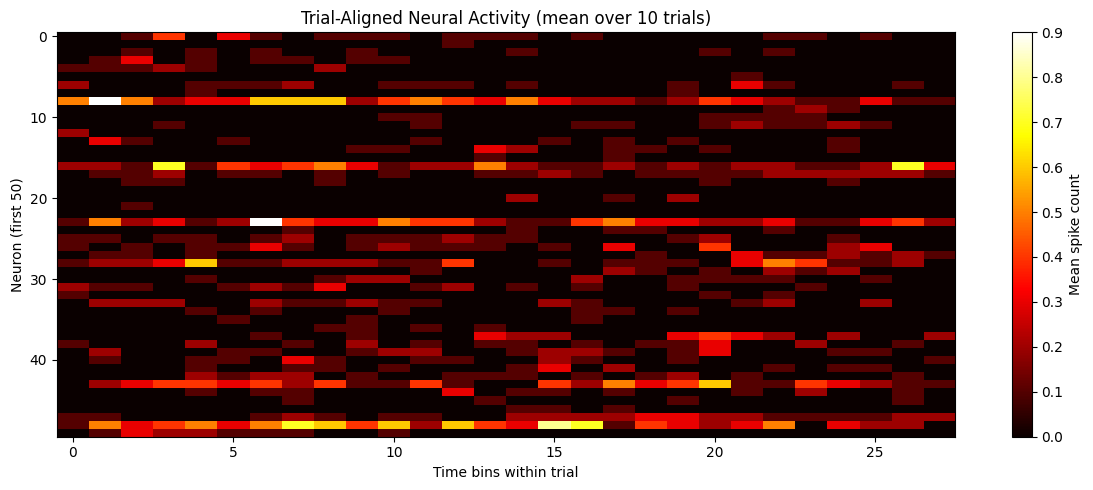

In [13]:
trials_df = nwb.trials.to_dataframe()

n_trials = 10
window = 0.7
n_samples = 28
trial_data = np.zeros((n_trials, n_samples, len(nwb.units)))

for i, (_, trial) in enumerate(trials_df.head(n_trials).iterrows()):
    t = np.linspace(trial["start_time"], trial["stop_time"], n_samples)
    res = experiment.interpolate(t)
    trial_data[i] = res["responses"]

fig, ax = plt.subplots(figsize=(12, 5))
mean_activity = trial_data.mean(axis=0)
im = ax.imshow(
    mean_activity[:, :n_neurons_to_plot].T,
    aspect="auto",
    cmap="hot",
    interpolation="nearest"
)
ax.set_xlabel("Time bins within trial")
ax.set_ylabel(f"Neuron (first {n_neurons_to_plot})")
ax.set_title(f"Trial-Aligned Neural Activity (mean over {n_trials} trials)")
plt.colorbar(im, label="Mean spike count")
plt.tight_layout()
plt.show()

## Additional Dataset: DANDI:000130

To verify generalizability, we also tested on DMFC_RSG —
macaque dorsomedial frontal cortex spiking activity during
a time interval reproduction task.

In [7]:
# Test on DANDI:000130 (DMFC_RSG)
# 40 neurons, 283 trials, 509s duration

from dandi.dandiapi import DandiAPIClient
import os

os.makedirs("data/000130", exist_ok=True)
client = DandiAPIClient()
d130 = client.get_dandiset("000130")
assets130 = list(d130.get_assets())
print(f"Downloading: {assets130[0].path} ({round(assets130[0].size/1e6, 2)} MB)")
assets130[0].download("data/000130/test.nwb")

Downloading: sub-Haydn/sub-Haydn_desc-test_ecephys.nwb (1.55 MB)


INFO:dandi:Asset a2c3ced1-2869-4483-aa19-8815c2d18c91 (1553584 bytes in 1 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/a2c3ced1-2869-4483-aa19-8815c2d18c91/download/


In [16]:
from pynwb import NWBHDF5IO

io130 = NWBHDF5IO("data/000130/test.nwb", "r")
nwb130 = io130.read()

fr130 = convert_nwb_to_experanto(
    nwb130,
    "experanto_000130",
    bin_size_ms=25
)

exp130 = Experiment("experanto_000130")
timestamps = np.linspace(0, 100, 200)
result130 = exp130.interpolate(timestamps)
data130 = result130["responses"]

print(f"DANDI:000130 — shape: {data130.shape}, "
      f"mean rate: {round(data130.mean(), 4)} spikes/bin")

io130.close()

Time range: 0.00s to 509.30s
Total duration: 509.30s

Bin size: 25ms → sampling rate: 40.0Hz
Number of time bins: 20372
Number of neurons: 40

Firing rate matrix shape: (20372, 40)
Mean firing rate: 0.1728 spikes/bin
Max firing rate: 8.0 spikes/bin

Saved data.npy → experanto_000130/responses/data.npy
Saved meta.yml → experanto_000130/responses/meta.yml
DANDI:000130 — shape: (200, 40), mean rate: 0.16899999976158142 spikes/bin


/usr/local/lib/python3.12/dist-packages/experanto/experiment.py:75: UserWarning: Falling back to original Interpolator creation logic.
  warnings.warn(


## Conclusion

This notebook demonstrated a complete pipeline for integrating
DANDI Archive datasets into Experanto.

**Tested datasets:**
-  DANDI:000128 — MC_Maze (macaque motor cortex, 137 neurons, 574 trials)
-  DANDI:000130 — DMFC_RSG (macaque frontal cortex, 40 neurons, 283 trials)
-  DANDI:000122 — fNIRS finger-tapping (incompatible — no spike units,
  requires separate converter for continuous signals)

The conversion pipeline works for any NWB dataset containing
`units` with `spike_times`. For continuous signals (fNIRS, LFP,
calcium imaging), a separate conversion approach is needed.